# 01 – Data Understanding & Preparation
**Projekt:** StepSense | ML4B SoSe 2026 | Gruppe: NoNames  
**CRISP-DM Phasen:** Data Understanding + Data Preparation

---

## Inhalt
1. Imports & Konfiguration
2. Daten einlesen
3. Data Understanding – Überblick & Qualitätsprüfung
4. Signalvisualisierung
5. Data Cleaning
6. Feature Engineering (Windowing)
7. Bias-Reflexion
8. Train / Validation / Test Split
9. Normalisierung
10. Export


## 1. Imports & Konfiguration

In [1]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Pfad zu den Rohdaten (relativ zum notebooks/ Ordner)
DATA_PATH = "../data/raw"
PROCESSED_PATH = "../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Relevante Sensordateien
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Orientation.csv"]

# Spalten je Sensor
SENSOR_COLUMNS = {
    "Accelerometer": ["x", "y", "z"],
    "Gyroscope":     ["x", "y", "z"],
    "Orientation":   ["roll", "pitch", "yaw"]
}

# Sensor-Prefix Mapping — explizit, damit "Accelerometer" -> "acc" (nicht "acce")
SENSOR_PREFIX = {
    "Accelerometer": "acc",
    "Gyroscope":     "gyro",
    "Orientation":   "orie",
}

# Windowing Parameter
WINDOW_SIZE_S = 2.0   # Fenstergrösse in Sekunden
OVERLAP       = 0.5   # 50% Ueberlappung
STEP_SIZE_S   = WINDOW_SIZE_S * (1 - OVERLAP)

# Trimming: Anfang und Ende jeder Session entfernen
# (Handy aus Hosentasche nehmen / wieder einstecken erzeugt Bewegungsartefakte)
TRIM_SECONDS = 2.0

# Split Parameter
TRAIN_SIZE = 0.70
VAL_SIZE   = 0.15
TEST_SIZE  = 0.15
RANDOM_STATE = 42

print("Setup abgeschlossen.")
print(f"Rohdaten:      {os.path.abspath(DATA_PATH)}")
print(f"Verarbeitet:   {os.path.abspath(PROCESSED_PATH)}")
print(f"Trim pro Ende: {TRIM_SECONDS}s  (gesamt {2*TRIM_SECONDS}s je Session)")

Setup abgeschlossen.
Rohdaten:      c:\Users\yanne\OneDrive\Uni\Wirtschaftsinformatik\6. Semester\ML4B\Projekt\ML4B\data\raw
Verarbeitet:   c:\Users\yanne\OneDrive\Uni\Wirtschaftsinformatik\6. Semester\ML4B\Projekt\ML4B\data\processed
Trim pro Ende: 2.0s  (gesamt 4.0s je Session)


## 2. Daten einlesen

Alle Sessions werden automatisch eingelesen. Das **Label** kommt direkt aus dem Klassenordner-Namen.

```
data/raw/
├── Gehen/
│   ├── Gehen_1_Yann/
│   │   ├── Accelerometer.csv
│   │   ├── Gyroscope.csv
│   │   └── Orientation.csv
│   └── ...
├── Stehen/
└── ...
```

Die drei Sensordateien werden ueber den Zeitstempel zusammengefuehrt (merge_asof, Toleranz 50ms).


In [2]:
def load_session(session_path, label):
    """Liest eine einzelne Session ein und merged die drei Sensordateien."""
    dfs = {}

    for sensor_file in SENSOR_FILES:
        sensor_name = sensor_file.replace(".csv", "")
        file_path = os.path.join(session_path, sensor_file)

        if not os.path.exists(file_path):
            return None

        df = pd.read_csv(file_path)

        # Zeitstempel: Nanosekunden -> Sekunden relativ zum Start
        df["time_s"] = (df["time"] - df["time"].iloc[0]) / 1e9
        df = df.drop(columns=["time", "seconds_elapsed"], errors="ignore")

        # Spalten umbenennen mit Sensor-Prefix (z.B. acc_, gyro_, orie_)
        prefix = SENSOR_PREFIX.get(sensor_name, sensor_name[:4].lower())
        cols = SENSOR_COLUMNS.get(sensor_name, [])
        rename_map = {c: f"{prefix}_{c}" for c in cols if c in df.columns}
        df = df.rename(columns=rename_map)
        keep = ["time_s"] + [f"{prefix}_{c}" for c in cols]
        df = df[[c for c in keep if c in df.columns]]
        dfs[sensor_name] = df

    if len(dfs) < 3:
        return None

    # Merge ueber Zeitstempel
    df_merged = dfs["Accelerometer"].sort_values("time_s")
    for name in ["Gyroscope", "Orientation"]:
        df_merged = pd.merge_asof(
            df_merged,
            dfs[name].sort_values("time_s"),
            on="time_s",
            direction="nearest",
            tolerance=0.05
        )

    df_merged["label"]   = label
    df_merged["session"] = os.path.basename(session_path)
    return df_merged


def load_all_data(data_path, exclude_classes=None):
    """Liest alle Klassen und Sessions ein."""
    exclude_classes = exclude_classes or []
    all_sessions, skipped = [], []

    for klasse in sorted(os.listdir(data_path)):
        if klasse.startswith(".") or klasse in exclude_classes:
            continue
        klasse_path = os.path.join(data_path, klasse)
        if not os.path.isdir(klasse_path):
            continue

        for session in sorted(os.listdir(klasse_path)):
            session_path = os.path.join(klasse_path, session)
            if not os.path.isdir(session_path):
                continue
            df = load_session(session_path, label=klasse)
            if df is not None and len(df) > 10:
                all_sessions.append(df)
            else:
                skipped.append(f"{klasse}/{session}")

    if skipped:
        print(f"Uebersprungen ({len(skipped)}): {skipped}")
    return all_sessions


# Mixed ausschliessen - wird spaeter fuer finale Klassifikation genutzt
sessions = load_all_data(DATA_PATH, exclude_classes=["Mixed"])
print(f"Erfolgreich geladen: {len(sessions)} Sessions")

Erfolgreich geladen: 16 Sessions


## 3. Data Understanding – Überblick & Qualitätsprüfung

In [3]:
# Uebersichtstabelle aller Sessions
summary_rows = []
for df in sessions:
    label    = df["label"].iloc[0]
    session  = df["session"].iloc[0]
    duration = df["time_s"].max() - df["time_s"].min()
    n        = len(df)
    summary_rows.append({
        "Klasse":            label,
        "Session":           session,
        "Samples":           n,
        "Dauer (s)":         round(duration, 1),
        "Sampling-Rate (Hz)": round(n / duration, 1) if duration > 0 else 0
    })

df_summary = pd.DataFrame(summary_rows)
print("=== Alle Sessions ===")
print(df_summary.to_string(index=False))


=== Alle Sessions ===
       Klasse         Session  Samples  Dauer (s)  Sampling-Rate (Hz)
        Gehen         Gehen_1     3616       59.1                61.2
        Gehen         Gehen_2    12565      125.5               100.1
        Gehen         Gehen_3    12778      127.7               100.1
        Gehen         Gehen_4      191       69.1                 2.8
       Laufen        Laufen_1    10170      101.6               100.1
       Laufen        Laufen_2    11435      114.3               100.1
       Liegen        Liegen_1      399       48.1                 8.3
       Liegen        Liegen_2    12324      123.2               100.0
       Liegen        Liegen_3    12245      122.3               100.1
       Stehen        Stehen_1    15316      153.0               100.1
       Stehen        Stehen_2     1608       26.3                61.2
       Stehen        Stehen_3    12885      128.7               100.1
  Treppe_hoch   Treppe_hoch_1      164       55.0                 3.

In [4]:
# Klassenverteilung
print("=== Klassenverteilung ===")
class_stats = df_summary.groupby("Klasse").agg(
    Sessions        = ("Session", "count"),
    Gesamt_Samples  = ("Samples", "sum"),
    Gesamt_Dauer_s  = ("Dauer (s)", "sum"),
    Ø_Sampling_Hz   = ("Sampling-Rate (Hz)", "mean")
).round(1)
print(class_stats.to_string())


=== Klassenverteilung ===
               Sessions  Gesamt_Samples  Gesamt_Dauer_s  Ø_Sampling_Hz
Klasse                                                                
Gehen                 4           29150           381.4           66.0
Laufen                2           21605           215.9          100.1
Liegen                3           24968           293.6           69.5
Stehen                3           29809           308.0           87.1
Treppe_hoch           2             332            77.7            5.2
Treppe_runter         2            2597            84.4           32.6


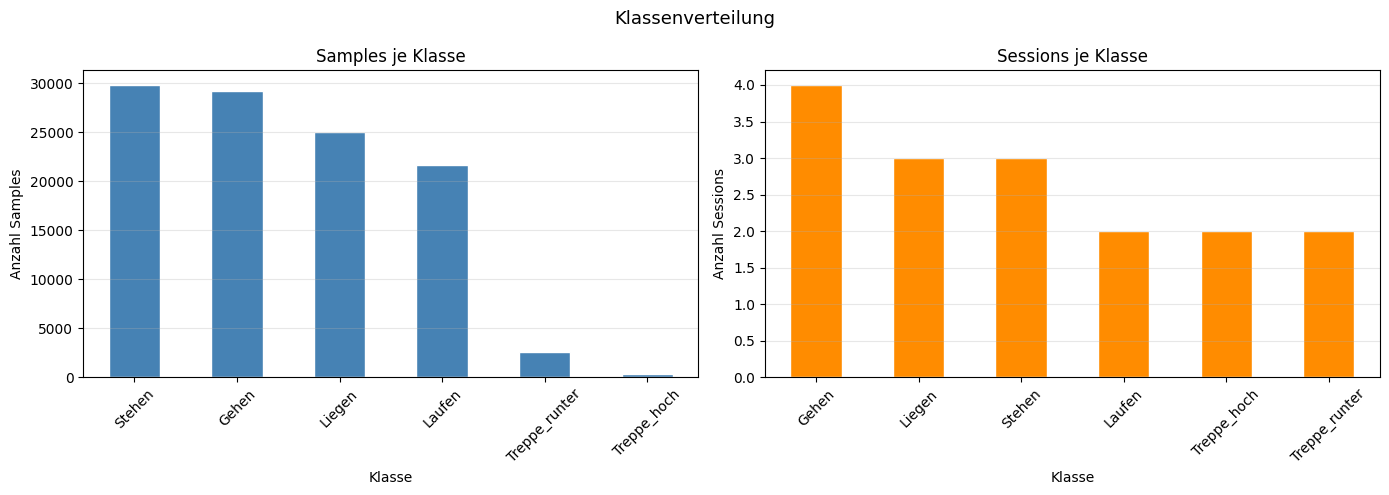

In [5]:
# Klassenverteilung visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Klassenverteilung", fontsize=13)

samples_per_class = df_summary.groupby("Klasse")["Samples"].sum().sort_values(ascending=False)
samples_per_class.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Samples je Klasse")
axes[0].set_ylabel("Anzahl Samples")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

sessions_per_class = df_summary.groupby("Klasse")["Session"].count().sort_values(ascending=False)
sessions_per_class.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Sessions je Klasse")
axes[1].set_ylabel("Anzahl Sessions")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
# Fehlende Werte & Sampling-Rate Konsistenz pruefen
print("=== Fehlende Werte je Session ===")
any_missing = False
for df in sessions:
    missing = df.isnull().sum().sum()
    if missing > 0:
        any_missing = True
        print(f"  {df['label'].iloc[0]}/{df['session'].iloc[0]}: {missing} fehlende Werte")
if not any_missing:
    print("  Keine fehlenden Werte gefunden.")

print("\n=== Sampling-Rate Konsistenz ===")
rate_stats = df_summary.groupby("Klasse")["Sampling-Rate (Hz)"].agg(["mean","min","max"]).round(1)
rate_stats.columns = ["Mittelwert (Hz)", "Min (Hz)", "Max (Hz)"]
print(rate_stats.to_string())
print("\nHinweis: Grosse Abweichungen zwischen Min und Max koennen auf fehlerhafte Sessions hinweisen.")


=== Fehlende Werte je Session ===
  Gehen/Gehen_1: 3 fehlende Werte
  Gehen/Gehen_4: 3 fehlende Werte
  Stehen/Stehen_2: 3 fehlende Werte
  Treppe_hoch/Treppe_hoch_1: 3 fehlende Werte
  Treppe_runter/Treppe_runter_1: 3 fehlende Werte
  Treppe_runter/Treppe_runter_2: 9 fehlende Werte

=== Sampling-Rate Konsistenz ===
               Mittelwert (Hz)  Min (Hz)  Max (Hz)
Klasse                                            
Gehen                     66.0       2.8     100.1
Laufen                   100.1     100.1     100.1
Liegen                    69.5       8.3     100.1
Stehen                    87.1      61.2     100.1
Treppe_hoch                5.2       3.0       7.4
Treppe_runter             32.6       4.0      61.2

Hinweis: Grosse Abweichungen zwischen Min und Max koennen auf fehlerhafte Sessions hinweisen.


## 4. Signalvisualisierung je Klasse

Klassen: ['Gehen', 'Laufen', 'Liegen', 'Stehen', 'Treppe_hoch', 'Treppe_runter']


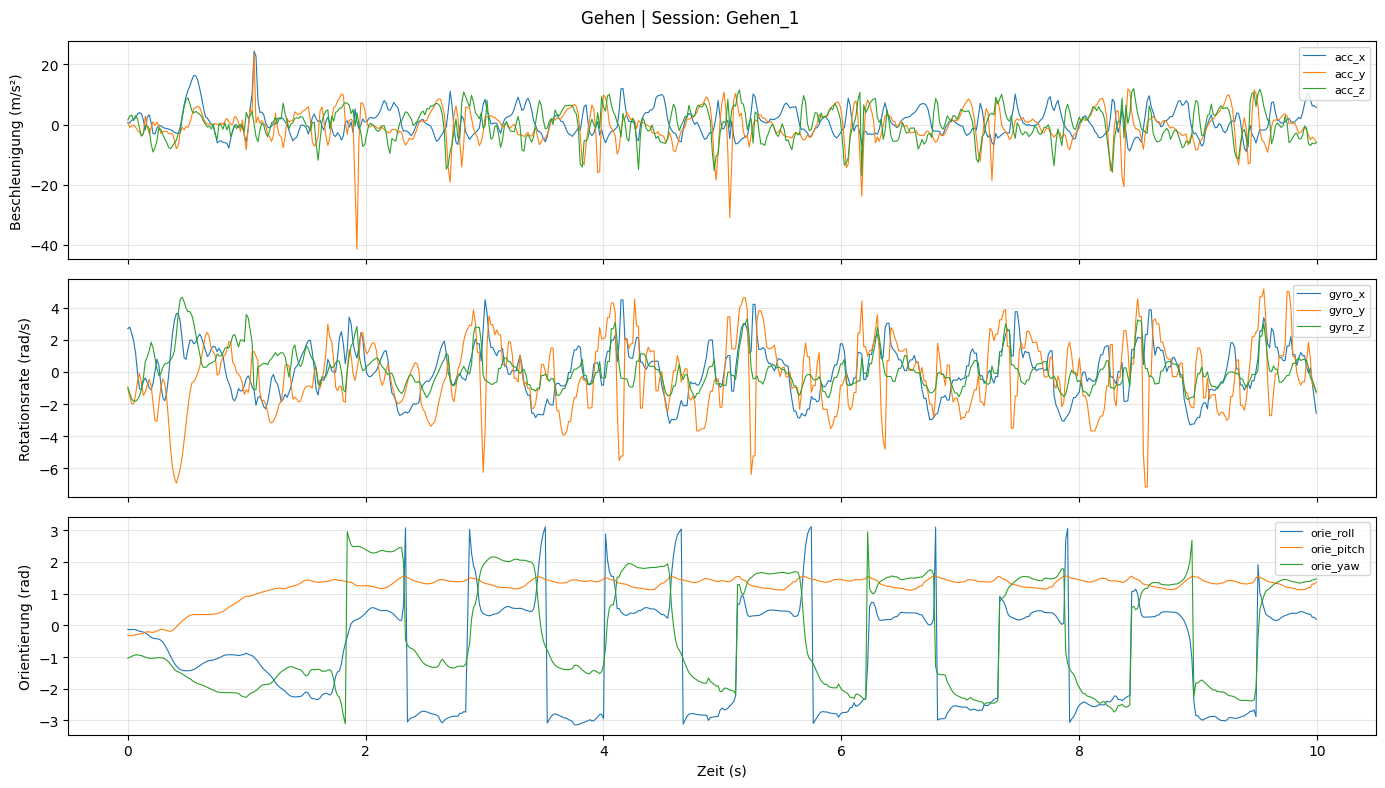

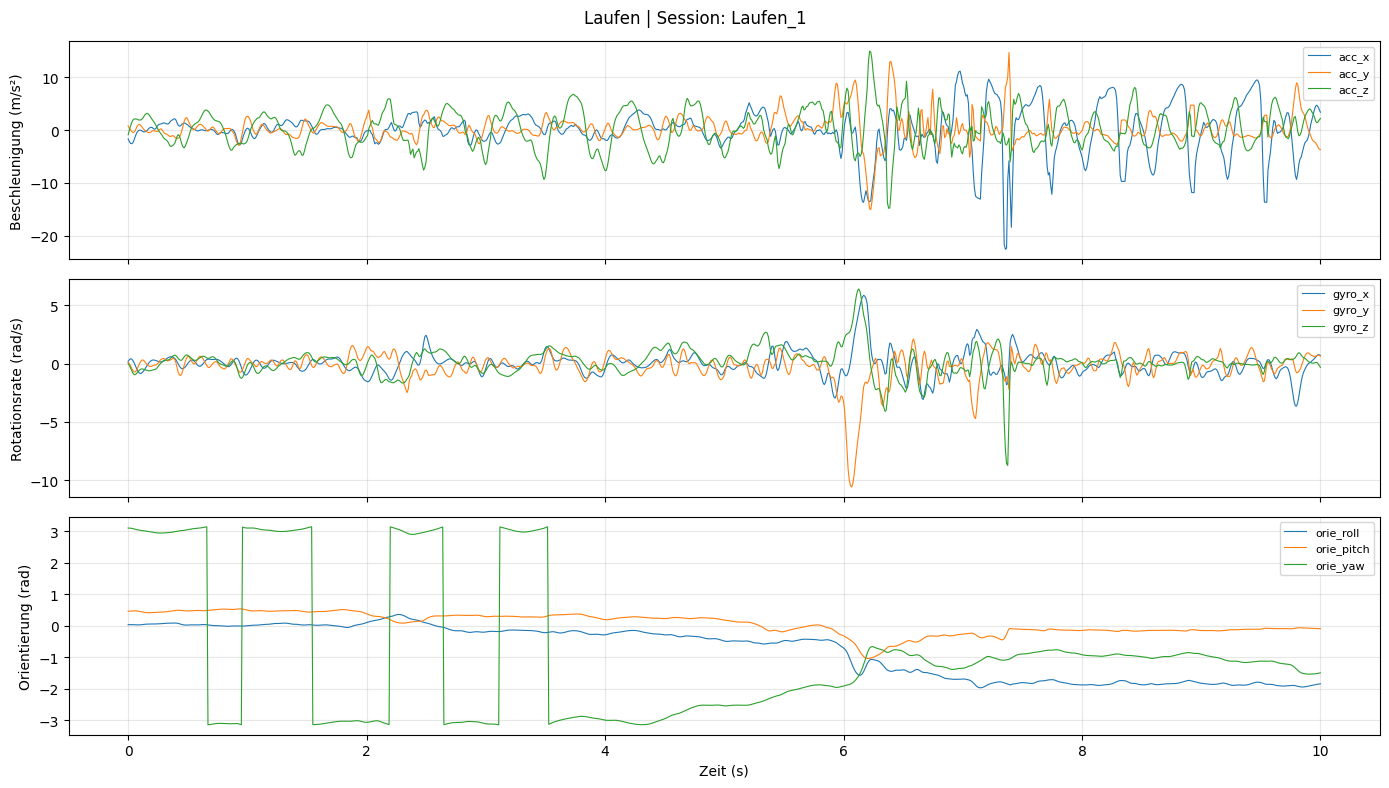

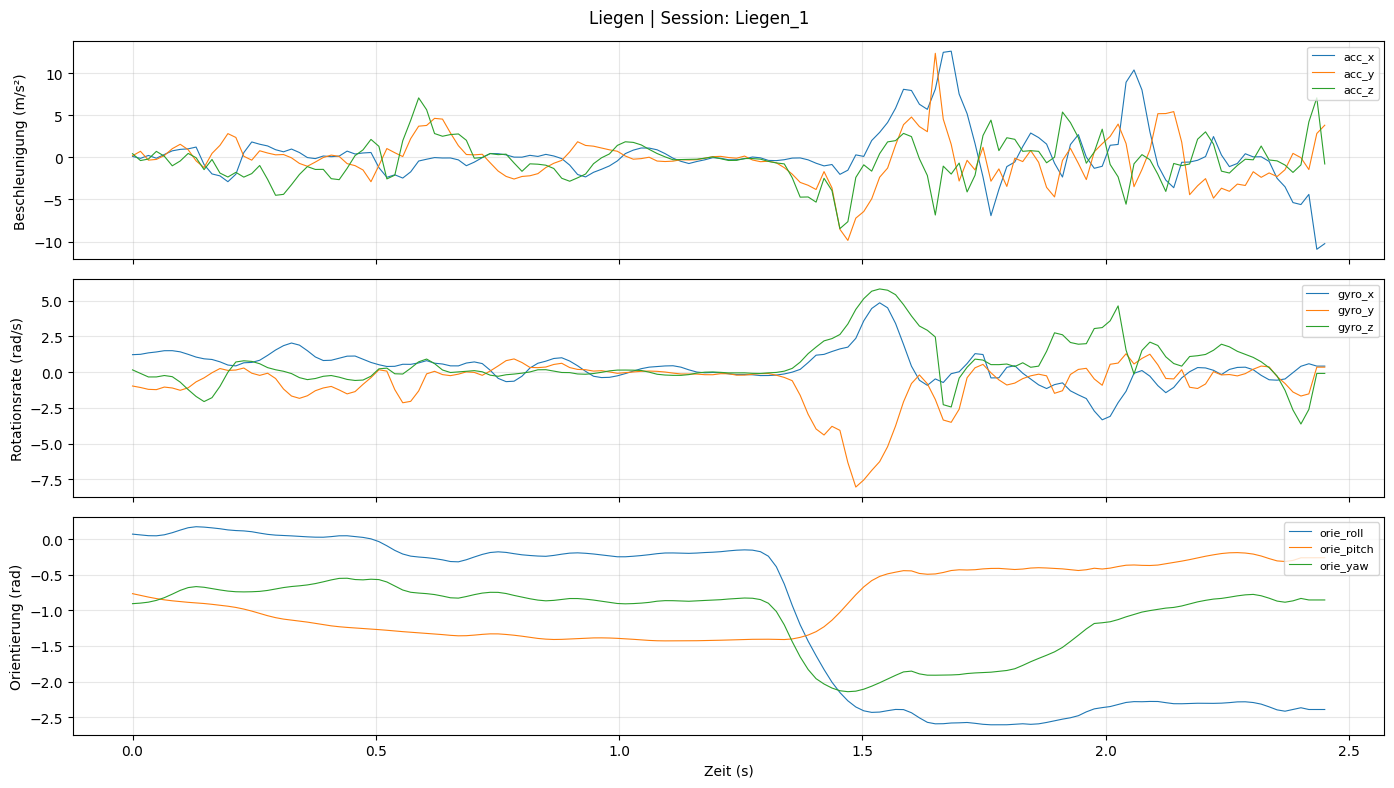

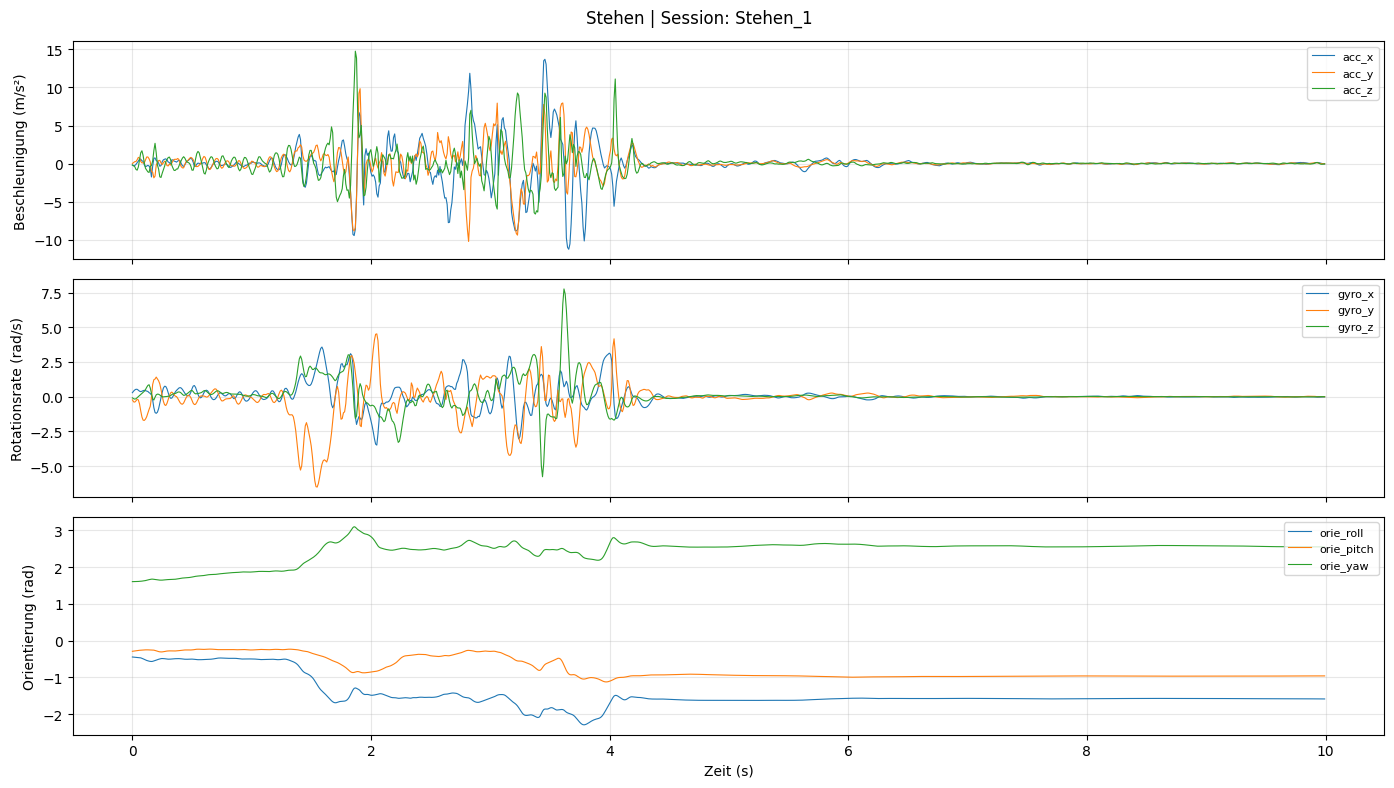

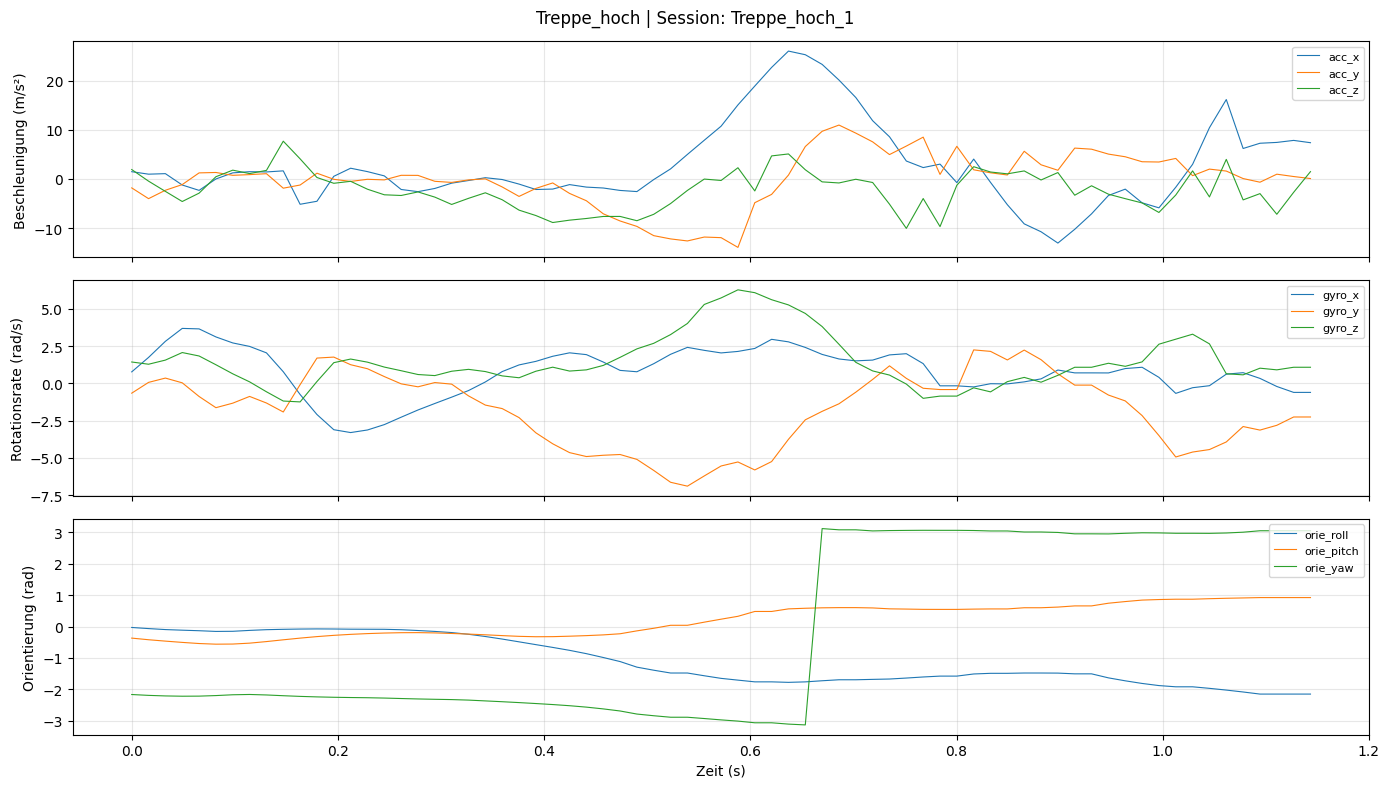

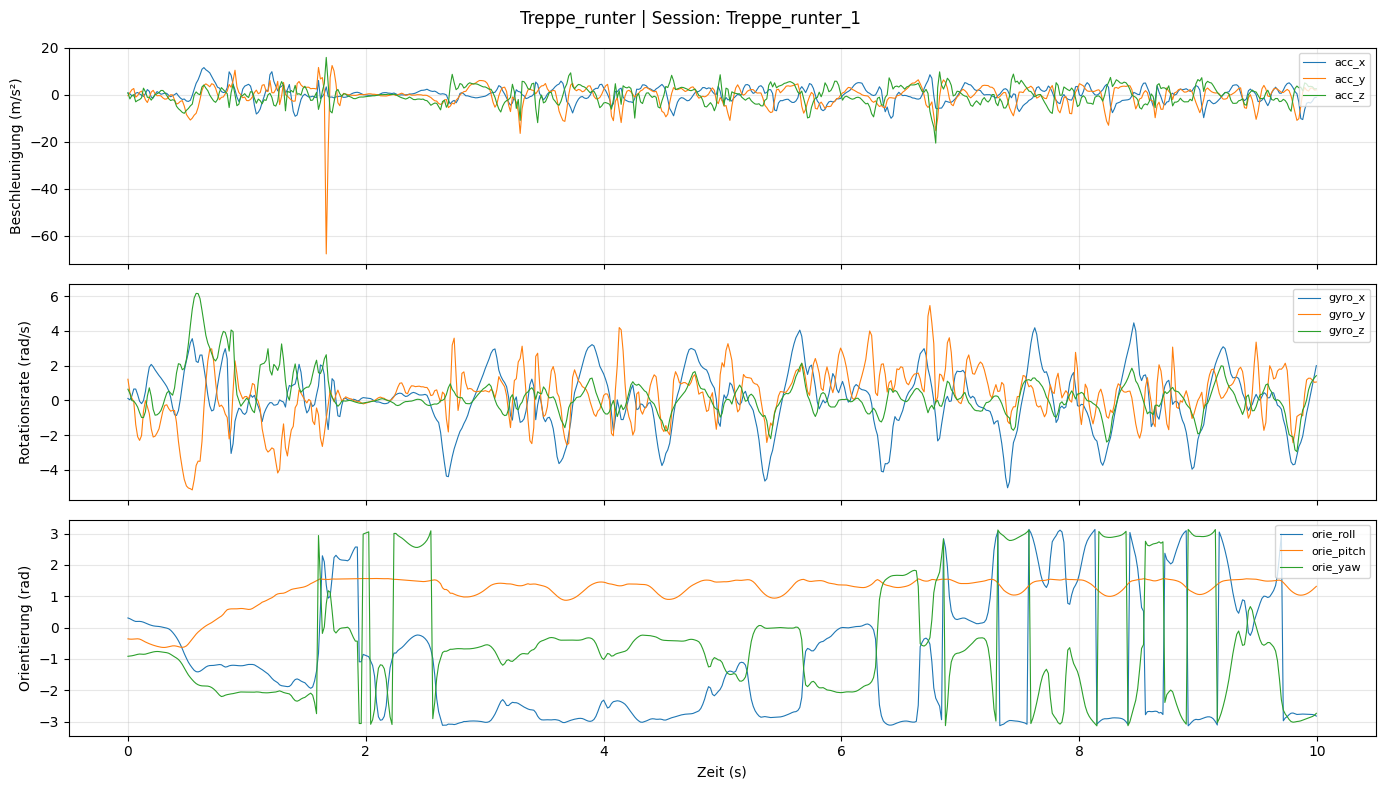

In [7]:
def plot_signals(sessions, klasse, max_seconds=10):
    """Plottet Acc, Gyro und Orientation fuer eine Beispiel-Session."""
    class_sessions = [df for df in sessions if df["label"].iloc[0] == klasse]
    if not class_sessions:
        print(f"Keine Sessions fuer: {klasse}")
        return

    df = class_sessions[0][lambda d: d["time_s"] <= max_seconds].copy()
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"{klasse} | Session: {df['session'].iloc[0]}", fontsize=12)

    sensor_groups = [
        (["acc_x","acc_y","acc_z"],          "Beschleunigung (m/s²)",  axes[0]),
        (["gyro_x","gyro_y","gyro_z"],        "Rotationsrate (rad/s)",  axes[1]),
        (["orie_roll","orie_pitch","orie_yaw"],"Orientierung (rad)",    axes[2]),
    ]
    for cols, ylabel, ax in sensor_groups:
        for col in cols:
            if col in df.columns:
                ax.plot(df["time_s"], df[col], label=col, linewidth=0.8)
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[2].set_xlabel("Zeit (s)")
    plt.tight_layout()
    plt.show()


available_classes = sorted(set(df["label"].iloc[0] for df in sessions))
print(f"Klassen: {available_classes}")
for klasse in available_classes:
    plot_signals(sessions, klasse)


## 5. Data Cleaning

Folgende Bereinigungsschritte werden angewendet:
1. **Trimming**: Erste und letzte `TRIM_SECONDS` Sekunden je Session entfernen — das Herausnehmen und Einstecken des Handys erzeugt Bewegungsartefakte, die nicht zur eigentlichen Aktivität gehören.
2. Duplikate im Zeitstempel entfernen
3. Sessions mit zu kurzer Aufnahmedauer entfernen (< 5 Sekunden nach dem Trim)
4. Fehlende Werte nach dem Sensor-Merge auffuellen (forward fill, dann backward fill)

In [ ]:
MIN_DURATION_S = 5.0   # Minimale Aufnahmedauer in Sekunden (nach Trim)
MAX_GAP_S      = 5.0   # Maximale erlaubte Luecke zwischen zwei Samples
                       # Groessere Luecken = Sensor-Logger pausiert -> Session verwerfen

cleaned_sessions = []
removed = []

for df in sessions:
    label   = df["label"].iloc[0]
    session = df["session"].iloc[0]

    # Duplikate entfernen
    df = df.drop_duplicates(subset=["time_s"])

    # Unterbrochene Aufnahmen erkennen (Sensor-Logger pausiert)
    max_gap = df["time_s"].diff().max()
    if max_gap > MAX_GAP_S:
        removed.append(f"{label}/{session}: unterbrochen (Luecke {max_gap:.1f}s > {MAX_GAP_S}s)")
        continue

    # Anfang und Ende trimmen (Handy aus/in Hosentasche nehmen erzeugt Rauschen)
    t_min = df["time_s"].min() + TRIM_SECONDS
    t_max = df["time_s"].max() - TRIM_SECONDS
    df = df[(df["time_s"] >= t_min) & (df["time_s"] <= t_max)].copy()

    # Zu kurze Sessions entfernen (nach dem Trim)
    duration = (df["time_s"].max() - df["time_s"].min()) if len(df) > 1 else 0
    if duration < MIN_DURATION_S:
        removed.append(f"{label}/{session}: zu kurz nach Trim ({duration:.1f}s)")
        continue

    # Fehlende Werte auffuellen
    sensor_cols = [c for c in df.columns if c not in ["time_s", "label", "session"]]
    df[sensor_cols] = df[sensor_cols].ffill().bfill()

    cleaned_sessions.append(df)

print(f"Sessions nach Cleaning: {len(cleaned_sessions)} (vorher: {len(sessions)})")
if removed:
    print("
Entfernt / Markiert:")
    for r in removed:
        print(f"  ! {r}")
else:
    print("Keine Sessions entfernt.")

trim_rows = []
for df in cleaned_sessions:
    label    = df["label"].iloc[0]
    session  = df["session"].iloc[0]
    duration = df["time_s"].max() - df["time_s"].min()
    n        = len(df)
    trim_rows.append({"Klasse": label, "Session": session,
                      "Samples": n, "Dauer_nach_Trim (s)": round(duration, 1),
                      "Hz": round(n / duration, 1) if duration > 0 else 0})
print("
=== Sessions nach Trim ===")
print(pd.DataFrame(trim_rows).to_string(index=False))

## 6. Feature Engineering – Windowing

Zeitreihendaten werden in **ueberlappende Fenster** aufgeteilt. Fuer jedes Fenster werden statistische Features berechnet (wie von der Vorlesung empfohlen: max, min, average, peaks).

| Parameter | Wert |
|-----------|------|
| Fenstergrösse | 2 Sekunden |
| Ueberlappung | 50% |
| Features je Signal | mean, std, min, max, range, energy, IQR, zero-crossing-rate |
| Signale | acc_x/y/z, gyro_x/y/z, orie_roll/pitch/yaw |
| Features gesamt | 9 Signale × 8 Features = **72 Features** |


In [9]:
FEATURE_COLS = [
    "acc_x",  "acc_y",  "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "orie_roll", "orie_pitch", "orie_yaw"
]

def compute_features(window):
    """Berechnet 8 statistische Features fuer jedes Signal in einem Fenster."""
    features = {}
    for col in FEATURE_COLS:
        if col not in window.columns:
            continue
        s = window[col].dropna()
        if len(s) < 5:
            continue
        features[f"{col}_mean"]   = s.mean()
        features[f"{col}_std"]    = s.std()
        features[f"{col}_min"]    = s.min()
        features[f"{col}_max"]    = s.max()
        features[f"{col}_range"]  = s.max() - s.min()
        features[f"{col}_energy"] = (s ** 2).mean()
        features[f"{col}_iqr"]    = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_zcr"]    = ((s.iloc[:-1].values * s.iloc[1:].values) < 0).sum() / len(s)
    return features


def session_to_windows(df):
    """Zerlegt eine Session in Fenster und berechnet Features je Fenster."""
    label   = df["label"].iloc[0]
    session = df["session"].iloc[0]
    t_start = df["time_s"].min()
    t_end   = df["time_s"].max()

    rows = []
    t = t_start
    while t + WINDOW_SIZE_S <= t_end:
        window = df[(df["time_s"] >= t) & (df["time_s"] < t + WINDOW_SIZE_S)]
        if len(window) >= 10:
            feats = compute_features(window)
            feats["label"]   = label
            feats["session"] = session
            rows.append(feats)
        t += STEP_SIZE_S
    return rows


# Alle Sessions verarbeiten
all_rows = []
for df in cleaned_sessions:
    all_rows.extend(session_to_windows(df))

df_features = pd.DataFrame(all_rows).fillna(0)

feature_cols = [c for c in df_features.columns if c not in ["label", "session"]]

print(f"Fenster gesamt:       {len(df_features)}")
print(f"Features je Fenster:  {len(feature_cols)}")
print(f"\nFenster je Klasse:")
print(df_features["label"].value_counts().to_string())


Fenster gesamt:       1065
Features je Fenster:  72

Fenster je Klasse:
label
Gehen            296
Stehen           292
Liegen           238
Laufen           205
Treppe_runter     34


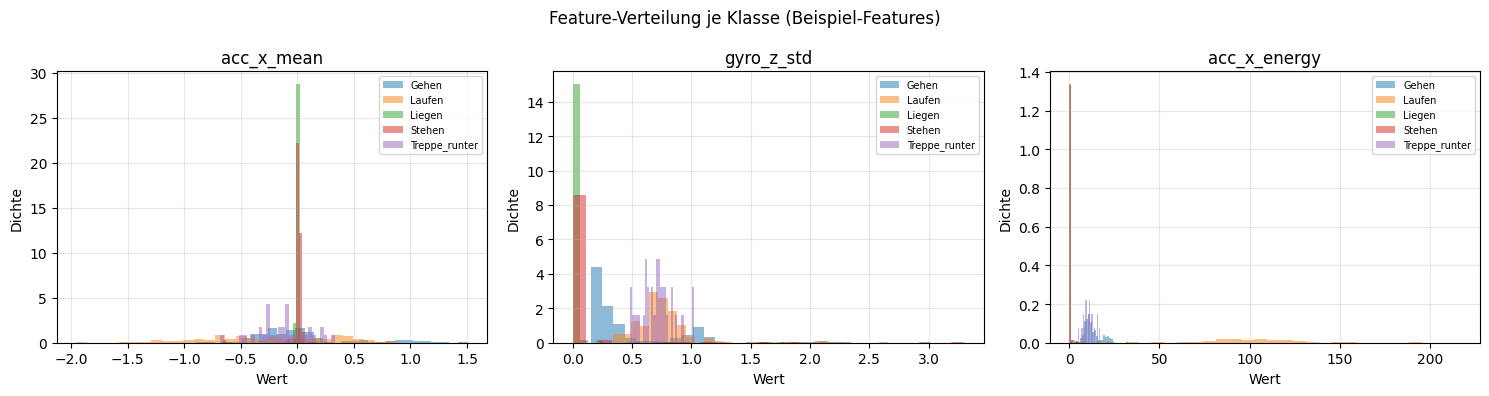

In [10]:
# Feature-Verteilung visualisieren (Beispiel: acc_x_mean je Klasse)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Feature-Verteilung je Klasse (Beispiel-Features)", fontsize=12)

example_features = ["acc_x_mean", "gyro_z_std", "acc_x_energy"]
for ax, feat in zip(axes, example_features):
    if feat not in df_features.columns:
        continue
    for klasse in df_features["label"].unique():
        vals = df_features[df_features["label"] == klasse][feat]
        ax.hist(vals, alpha=0.5, label=klasse, bins=30, density=True)
    ax.set_title(feat)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/feature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Bias-Reflexion

Gemaess Vorlesung ist es wichtig, potenzielle Bias-Quellen zu identifizieren und zu dokumentieren.

### Identifizierte Bias-Quellen

| Bias-Quelle | Beschreibung | Auswirkung |
|-------------|-------------|------------|
| **Wenige Personen** | Aufnahmen von nur 2-3 Personen | Modell lernt individuelle Gangmuster, generalisiert schlecht auf unbekannte Personen |
| **Geräteposition** | Handy immer in der rechten Hosentasche | Funktioniert nicht für andere Trageweisen (Jackentasche, Hand, Rucksack) |
| **Umgebung** | Aufnahmen in ähnlichen Umgebungen | Treppenerkennung z.B. nur für bekannte Treppen kalibriert |
| **Tageszeit** | Aufnahmen zu ähnlichen Tageszeiten | Muedigkeit oder Energielevel beeinflusst Gangmuster |
| **Klassenungleichgewicht** | Manche Klassen haben mehr Aufnahmen | Modell bevorzugt haeufige Klassen → wird durch stratifizierten Split gemindert |

### Massnahmen

- Stratifizierter Train/Val/Test-Split um Klassenungleichgewicht zu kontrollieren
- Mixed-Ordner wird separat gehalten fuer unabhaengige finale Evaluation
- Alle Teammitglieder haben Aufnahmen gemacht um Personenbias zu reduzieren


## 8. Train / Validation / Test Split

Gemaess Vorlesung: 70% Train / 15% Validation / 15% Test  
Stratifizierter Split um Klassenverteilung zu erhalten.


In [11]:
X = df_features[feature_cols]
y = df_features["label"]

# Schritt 1: 70% Train, 30% temporaer
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=1 - TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Schritt 2: 30% temporaer -> 50% Val, 50% Test (= je 15% vom Gesamt)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train:      {X_train.shape[0]:>5} Fenster ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]:>5} Fenster ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]:>5} Fenster ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nKlassenverteilung Train:")
print(y_train.value_counts().to_string())


Train:        745 Fenster (70%)
Validation:   160 Fenster (15%)
Test:         160 Fenster (15%)

Klassenverteilung Train:
label
Gehen            207
Stehen           204
Liegen           167
Laufen           143
Treppe_runter     24


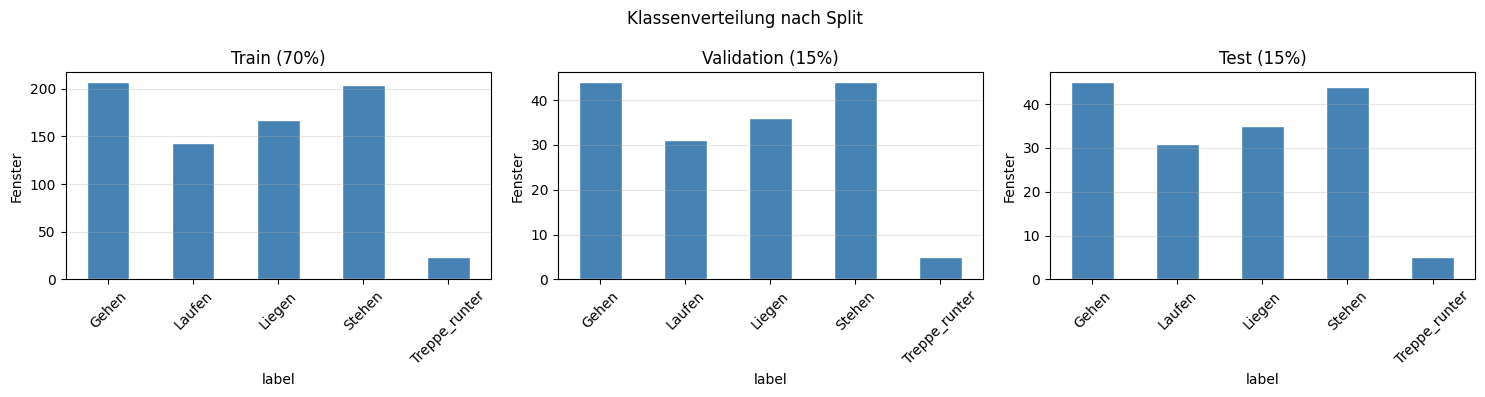

In [12]:
# Klassenverteilung im Split visualisieren
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Klassenverteilung nach Split", fontsize=12)

for ax, (y_part, title) in zip(axes, [(y_train, "Train (70%)"), (y_val, "Validation (15%)"), (y_test, "Test (15%)")]):
    y_part.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Fenster")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Normalisierung

Feature Standardization: Mittelwert = 0, Standardabweichung = 1  
Der Scaler wird **nur auf den Trainingsdaten** gefittet und dann auf Val und Test angewendet.  
So verhindert man Data Leakage.


In [13]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols, index=X_test.index)

sample_feat = feature_cols[0]
print("Normalisierung abgeschlossen.")
print(f"Mittelwert Train ({sample_feat}): {X_train_scaled[sample_feat].mean():.4f}")
print(f"Std Train        ({sample_feat}): {X_train_scaled[sample_feat].std():.4f}")

Normalisierung abgeschlossen.
Mittelwert Train (acc_x_mean): -0.0000
Std Train        (acc_x_mean): 1.0007


## 10. Export nach `data/processed/`

In [14]:
# CSV Export
df_features.to_csv(f"{PROCESSED_PATH}/features_all.csv", index=False)
X_train_scaled.to_csv(f"{PROCESSED_PATH}/X_train.csv", index=False)
X_val_scaled.to_csv(f"{PROCESSED_PATH}/X_val.csv",     index=False)
X_test_scaled.to_csv(f"{PROCESSED_PATH}/X_test.csv",   index=False)
y_train.to_csv(f"{PROCESSED_PATH}/y_train.csv", index=False)
y_val.to_csv(f"{PROCESSED_PATH}/y_val.csv",     index=False)
y_test.to_csv(f"{PROCESSED_PATH}/y_test.csv",   index=False)

# Scaler & Feature-Namen speichern (benoetigt fuer app.py)
with open(f"{PROCESSED_PATH}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(f"{PROCESSED_PATH}/feature_names.txt", "w") as f:
    f.write("\n".join(feature_cols))

print("Gespeichert in data/processed/:")
for fname in sorted(os.listdir(PROCESSED_PATH)):
    size = os.path.getsize(f"{PROCESSED_PATH}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")


Gespeichert in data/processed/:
  X_test.csv                                       228,705 bytes
  X_train.csv                                    1,061,317 bytes
  X_val.csv                                        228,237 bytes
  class_distribution.png                            66,429 bytes
  feature_distribution.png                          56,064 bytes
  feature_names.txt                                    964 bytes
  features_all.csv                               1,412,659 bytes
  scaler.pkl                                         3,312 bytes
  split_distribution.png                            49,137 bytes
  y_test.csv                                         1,277 bytes
  y_train.csv                                        5,928 bytes
  y_val.csv                                          1,278 bytes


## Zusammenfassung

### Data Understanding
- Alle Sessions aus `data/raw/` erfolgreich eingelesen
- Sampling-Raten und fehlende Werte geprueft
- Signalverlaeufe je Klasse visualisiert
- Klassenverteilung analysiert

### Data Cleaning
- Sessions unter 5 Sekunden entfernt
- Zeitstempel-Duplikate entfernt
- Fehlende Werte per Forward/Backward-Fill aufgefuellt

### Feature Engineering
- Windowing: 2 Sekunden, 50% Ueberlappung
- 8 statistische Features je Signal (mean, std, min, max, range, energy, IQR, ZCR)
- 9 Signale × 8 Features = **72 Features** gesamt

### Bias-Reflexion
- Personenbias (wenige Aufnehmende), Positionsbias (Hosentasche), Umgebungsbias dokumentiert
- Stratifizierter Split als Gegenmassnahme

### Data Splitting
- Train 70% / Validation 15% / Test 15%
- Stratifiziert nach Klasse

### Normalisierung
- StandardScaler (fit nur auf Train, transform auf Val und Test)

**Naechster Schritt:** `02_modeling_baseline.ipynb`
